<a href="https://colab.research.google.com/github/umeeazhar143-wq/student-performance-analysis/blob/main/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")

print(df.head())
print("Dataset shape:", df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
Dataset shape: (395, 33)


In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
print("Average Final Grade:", df["G3"].mean())
print("Highest Final Grade:", df["G3"].max())
print("Lowest Final Grade:", df["G3"].min())

print("\nAverage Final Grade by Gender:")
print(df.groupby("sex")["G3"].mean())

Average Final Grade: 10.415189873417722
Highest Final Grade: 20
Lowest Final Grade: 0

Average Final Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


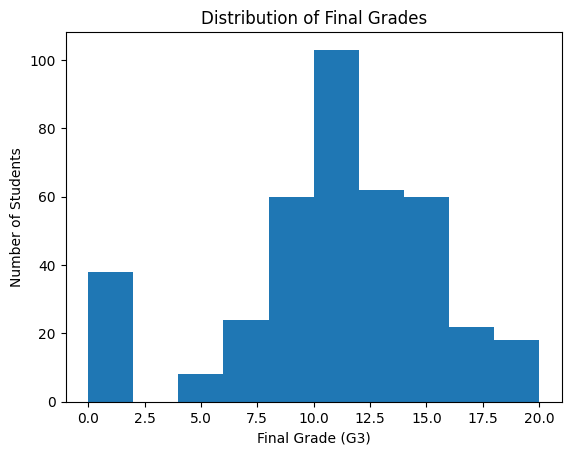

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["G3"], bins=10)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

In [7]:
print("Average Final Grade by Study Time:")
print(df.groupby("studytime")["G3"].mean())

Average Final Grade by Study Time:
studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


In [8]:
print("\nAverage Final Grade by Number of Failures:")
print(df.groupby("failures")["G3"].mean())


Average Final Grade by Number of Failures:
failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64


In [9]:
print("\nAverage Final Grade by Absence Level:")
print(df.groupby("absences")["G3"].mean())


Average Final Grade by Absence Level:
absences
0      8.443478
1     13.000000
2     11.907692
3     11.500000
4     11.283019
5     11.600000
6     11.774194
7     11.857143
8     10.590909
9     13.333333
10    11.235294
11    11.666667
12    10.750000
13    12.666667
14     9.333333
15     8.333333
16     9.857143
17    10.000000
18     8.400000
19    10.000000
20    11.500000
21    18.000000
22     8.000000
23    13.000000
24    18.000000
25    11.000000
26     6.000000
28     9.000000
30     8.000000
38     8.000000
40    11.000000
54    11.000000
56     8.000000
75     9.000000
Name: G3, dtype: float64


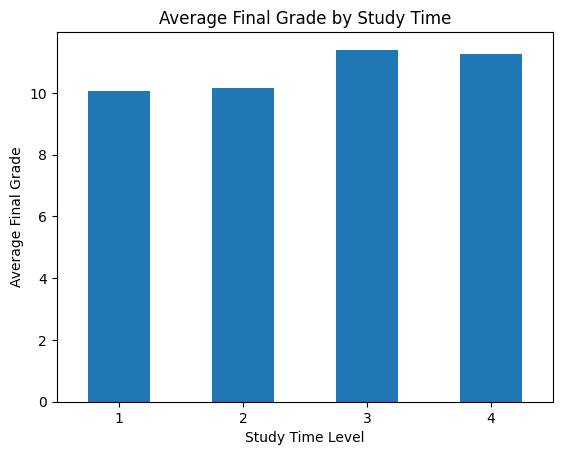

In [10]:
import matplotlib.pyplot as plt

study_grade = df.groupby("studytime")["G3"].mean()

study_grade.plot(kind="bar")

plt.xlabel("Study Time Level")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")
plt.xticks(rotation=0)
plt.show()

In [11]:
df["absence_group"] = pd.cut(
    df["absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=["0-5", "6-10", "11-20", "21+"]
)

print("Average Final Grade by Absence Group:")
print(df.groupby("absence_group", observed=True)["G3"].mean())

Average Final Grade by Absence Group:
absence_group
0-5      10.168675
6-10     11.400000
11-20    10.117647
21+      10.266667
Name: G3, dtype: float64


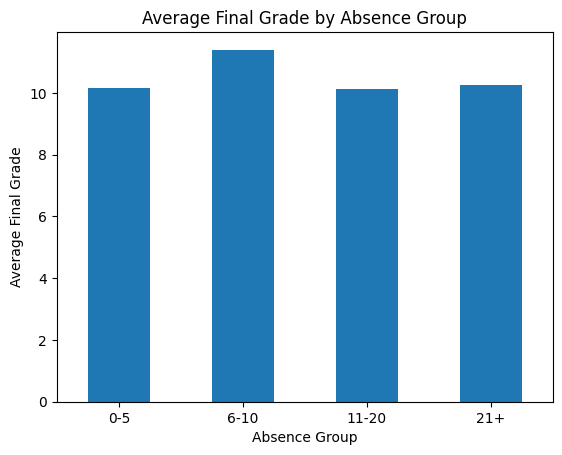

In [12]:
absence_grade = df.groupby(
    "absence_group",
    observed=True
)["G3"].mean()

absence_grade.plot(kind="bar")

plt.xlabel("Absence Group")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Absence Group")
plt.xticks(rotation=0)
plt.show()

In [13]:
print("Correlation with Final Grade (G3):")
print(df[["G1", "G2", "studytime", "failures", "absences", "G3"]].corr()["G3"].sort_values(ascending=False))

Correlation with Final Grade (G3):
G3           1.000000
G2           0.904868
G1           0.801468
studytime    0.097820
absences     0.034247
failures    -0.360415
Name: G3, dtype: float64


In [14]:
print("Average Final Grade by Previous Failures:")
print(df.groupby("failures")["G3"].agg(["count", "mean"]))

Average Final Grade by Previous Failures:
          count       mean
failures                  
0           312  11.253205
1            50   8.120000
2            17   6.235294
3            16   5.687500


In [15]:
print("\nAverage Final Grade by School:")
print(df.groupby("school")["G3"].agg(["count", "mean"]))


Average Final Grade by School:
        count       mean
school                  
GP        349  10.489971
MS         46   9.847826


In [16]:
print("\nAverage Final Grade by Gender:")
print(df.groupby("sex")["G3"].agg(["count", "mean"]))


Average Final Grade by Gender:
     count       mean
sex                  
F      208   9.966346
M      187  10.914439


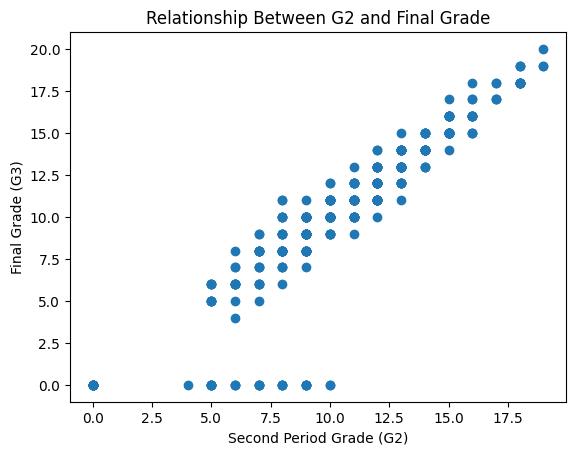

In [17]:
plt.scatter(df["G2"], df["G3"])

plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.title("Relationship Between G2 and Final Grade")

plt.show()

In [18]:
df["performance_group"] = df["G3"].apply(
    lambda x: "At Risk" if x < 10 else "Passing"
)

print("Student Performance Groups:")
print(df["performance_group"].value_counts())

print("\nPerformance Group Analysis:")
print(
    df.groupby("performance_group")[["G1", "G2", "G3", "failures", "absences"]]
    .mean()
)

Student Performance Groups:
performance_group
Passing    265
At Risk    130
Name: count, dtype: int64

Performance Group Analysis:
                          G1         G2         G3  failures  absences
performance_group                                                     
At Risk             7.761538   6.823077   5.384615  0.692308  6.761538
Passing            12.452830  12.622642  12.883019  0.158491  5.192453


In [19]:
print("\nPerformance Group Percentage:")
print(
    df["performance_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Performance Group Percentage:
performance_group
Passing    67.09
At Risk    32.91
Name: proportion, dtype: float64


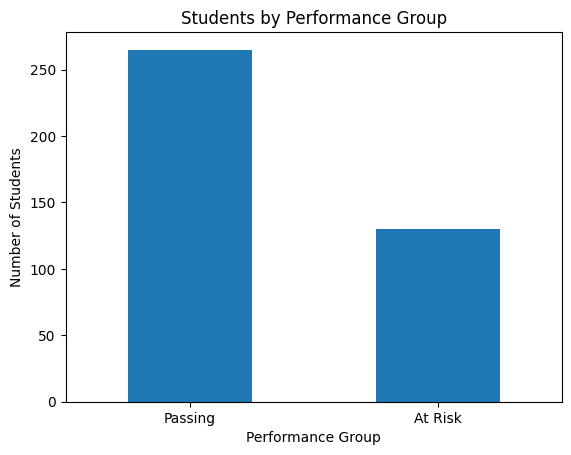

In [20]:
performance_count = df["performance_group"].value_counts()

performance_count.plot(kind="bar")

plt.xlabel("Performance Group")
plt.ylabel("Number of Students")
plt.title("Students by Performance Group")
plt.xticks(rotation=0)
plt.show()